# 1) Bağımlılıklar

In [1]:
!pip install -qU llama-index
!pip install -qU llama-index-embeddings-huggingface
!pip install -qU llama-index-retrievers-bm25
!pip install -qU llama-index-postprocessor-flag-embedding-reranker
!pip install -qU sentence-transformers rank_bm25 nest_asyncio
!pip install FlagEmbedding
!pip install matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 2) Setup

In [ ]:
import os
os.environ["HF_TOKEN"] = ""

import nest_asyncio
nest_asyncio.apply()

import pandas as pd
import asyncio
import gc
import torch
import json
import glob
from typing import List

from llama_index.core import VectorStoreIndex, Document, Settings
from llama_index.core.node_parser import SentenceSplitter, MarkdownNodeParser
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.postprocessor.flag_embedding_reranker import FlagEmbeddingReranker
from llama_index.core.evaluation import QueryResponseDataset
from llama_index.core import SimpleDirectoryReader
from llama_index.core.indices.query.schema import QueryBundle
from llama_index.core.llms import MockLLM
Settings.llm = MockLLM() # OpenAI API kontrolünü tamamen devre dışı bırakır

# ── GPU TESPİTİ ──
print(f"🖥️  Kullanılabilir GPU: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    name = torch.cuda.get_device_name(i)
    mem = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"   cuda:{i} → {name} ({mem:.1f} GB)")

print("\n⚠️ DİKKAT: Bu notebook 100% stabilite için sadece cuda:0'ı kullanacaktır.")

all_results = []

def add_result(group, model_name, mrr, hit_rate):
    all_results.append({
        "Group": group,
        "System": model_name,
        "MRR@5": round(mrr, 4),
        "HitRate@5": round(hit_rate, 4)
    })
    print(f"  ✅ [{group}] {model_name} → MRR: {mrr:.4f} | Hit Rate: {hit_rate:.4f}")

# ── BATCH DEĞERLENDİRİCİ (Batch Embedding Desteği ve OOM önleyici) ──
async def evaluate_retriever_custom(retriever, queries_dict, relevant_docs_dict,
                                     top_k=5, max_concurrent=15, batch_size=100,
                                     embed_model=None):
    sem = asyncio.Semaphore(max_concurrent)
    
    # ── BATCH EMBEDDING HIZLANDIRMASI ──
    query_embeddings_dict = {}
    if embed_model is not None:
        try:
            print("      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...")
            q_ids = list(queries_dict.keys())
            q_texts = list(queries_dict.values())
            
            # HuggingFace modelinde toplu vektörleştirme 32'şerli batch'lerle saniyeler içinde yapılır
            embeddings = embed_model.get_text_embedding_batch(q_texts, show_progress=True)
            query_embeddings_dict = {q_ids[i]: embeddings[i] for i in range(len(q_ids))}
            print("      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...")
        except Exception as e:
            print(f"      ⚠️ Toplu vektörleştirme başarısız oldu, klasik yöntemle devam ediliyor: {e}")
            query_embeddings_dict = {}

    async def process_single_query(q_id, query_str, expected_ids):
        if not expected_ids:
            return None
        expected_ids_clean = [str(eid).strip().split(".")[0] for eid in expected_ids]

        async with sem:
            try:
                # Eğer önceden hesaplanmış vektör varsa doğrudan QueryBundle ile besleyelim (GPU çağrı sayısını 2132'den 1'e düşürür!)
                if query_embeddings_dict and q_id in query_embeddings_dict:
                    from llama_index.core.indices.query.schema import QueryBundle
                    bundle = QueryBundle(
                        query_str=query_str,
                        embedding=query_embeddings_dict[q_id]
                    )
                    retrieved_nodes = await retriever.aretrieve(bundle)
                else:
                    retrieved_nodes = await retriever.aretrieve(query_str)
                
                retrieved_nodes = retrieved_nodes[:top_k]

                retrieved_doc_ids = []
                for n in retrieved_nodes:
                    possible_ids = []
                    if getattr(n.node, "ref_doc_id", None):
                        possible_ids.append(n.node.ref_doc_id)
                    if getattr(n.node, "node_id", None):
                        possible_ids.append(n.node.node_id)
                    if n.node.metadata and "file_name" in n.node.metadata:
                        possible_ids.append(n.node.metadata["file_name"])

                    for pid in possible_ids:
                        clean_pid = str(pid).strip().split(".")[0]
                        if clean_pid not in retrieved_doc_ids:
                            retrieved_doc_ids.append(clean_pid)

                hit = 1.0 if any(eid in retrieved_doc_ids for eid in expected_ids_clean) else 0.0

                mrr = 0.0
                for rank, doc_id in enumerate(retrieved_doc_ids):
                    if doc_id in expected_ids_clean:
                        mrr = 1.0 / (rank + 1)
                        break
                return (mrr, hit)
            except Exception as e:
                return None

    all_items = list(queries_dict.items())
    all_query_results = []
    total_batches = (len(all_items) + batch_size - 1) // batch_size

    for i in range(0, len(all_items), batch_size):
        batch = all_items[i : i + batch_size]
        batch_num = i // batch_size + 1
        print(f"    Batch {batch_num}/{total_batches} ({len(batch)} sorgu)...", end="\r")

        tasks = [
            process_single_query(q_id, q_str, relevant_docs_dict.get(q_id, []))
            for q_id, q_str in batch
        ]
        batch_results = await asyncio.gather(*tasks)
        all_query_results.extend(batch_results)

    print(f"    ✓ {len(all_items)} sorgu tamamlandı.                        ")

    valid_results = [r for r in all_query_results if r is not None]
    if not valid_results:
        return 0.0, 0.0

    avg_mrr = sum(r[0] for r in valid_results) / len(valid_results)
    avg_hit = sum(r[1] for r in valid_results) / len(valid_results)
    return avg_mrr, avg_hit

print("✅ Setup tamamlandı.")

🖥️  Kullanılabilir GPU: 2
   cuda:0 → Tesla T4 (14.6 GB)
   cuda:1 → Tesla T4 (14.6 GB)

⚠️ DİKKAT: Bu notebook 100% stabilite için sadece cuda:0'ı kullanacaktır.
✅ Setup tamamlandı.


# 3) Veri Yükleme

In [3]:
# BASE_PATH Kendi yolunuza göre ayarlayın
BASE_PATH = "/kaggle/input/datasets/yekbun/turkish-rag-dataset/rag-dataset"

QA_PATH   = os.path.join(BASE_PATH, "benchmark")
DOCS_PATH = os.path.join(BASE_PATH, "stage2_cleaned")

print("1. Dokümanlar yükleniyor...")
reader = SimpleDirectoryReader(input_dir=DOCS_PATH, recursive=True, required_exts=[".md", ".txt"])
documents = reader.load_data()

for doc in documents:
    doc.id_ = doc.metadata["file_name"].replace(".md", "").replace(".txt", "").strip()

print(f"   Toplam Doküman: {len(documents)}")

print("\n2. QA Çiftleri yükleniyor...")
queries = {}
relevant_docs = {}

qa_files = glob.glob(os.path.join(QA_PATH, "*.json"))

for file_path in qa_files:
    try:
        temp_dataset = QueryResponseDataset.from_json(file_path)
        queries.update(temp_dataset.queries)
        for k, v in temp_dataset.relevant_docs.items():
            relevant_docs[k] = relevant_docs.get(k, []) + v
    except Exception:
        with open(file_path, "r", encoding="utf-8") as f:
            qa_data = json.load(f)

        for idx, item in enumerate(qa_data):
            q_id = item.get("id", item.get("query_id", f"{os.path.basename(file_path)}_{idx}"))
            queries[q_id] = item.get("query", item.get("question", ""))

            exp_docs = item.get("source_file", item.get("expected_doc_id", item.get("doc_id", [])))
            if not isinstance(exp_docs, list):
                exp_docs = [exp_docs]
            relevant_docs[q_id] = exp_docs

TEST_LIMIT = None  # Hızlı test için sayı verebilirsiniz (örn: 50)
if TEST_LIMIT and TEST_LIMIT < len(queries):
    queries = dict(list(queries.items())[:TEST_LIMIT])
    relevant_docs = {k: relevant_docs.get(k, []) for k in queries.keys()}

print(f"   Toplam Soru: {len(queries)}")

1. Dokümanlar yükleniyor...
   Toplam Doküman: 235

2. QA Çiftleri yükleniyor...
   Toplam Soru: 2132


# 4) Grup 1: Embedding Modeli Karşılaştırması

In [4]:
print("\n" + "=" * 60)
print("  GRUP 1: EMBEDDING MODELİ KARŞILAŞTIRMASI")
print("=" * 60)

embedding_models = {
    "RAG-1": "BAAI/bge-m3",
    "RAG-2": "intfloat/multilingual-e5-large",
    "RAG-3": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
}

group1_results = []

async def _eval_embedding(rag_id, model_name):
    print(f"\n🚀 {rag_id} ({model_name.split('/')[-1]}) değerlendiriliyor...")

    embed_model = HuggingFaceEmbedding(
        model_name=model_name,
        device="cuda:0",
        embed_batch_size=32, 
    )

    index = VectorStoreIndex.from_documents(
        documents,
        embed_model=embed_model,
        transformations=[SentenceSplitter(chunk_size=512, chunk_overlap=128)],
    )
    retriever = index.as_retriever(similarity_top_k=5)

    mrr, hit_rate = await evaluate_retriever_custom(
        retriever, queries, relevant_docs,
        top_k=5, max_concurrent=20, batch_size=100,
        embed_model=embed_model,
    )

    add_result("Group 1", f"{rag_id} ({model_name.split('/')[-1]})", mrr, hit_rate)
    group1_results.append({"name": model_name, "mrr": mrr})

    # Çok derin hafıza temizliği (LlamaIndex arka plan sızıntılarını engellemek için)
    try:
        del embed_model._model
    except:
        pass
    try:
        del embed_model.model
    except:
        pass
    
    del index
    del retriever
    del embed_model
    
    for _ in range(3):
        gc.collect()
        
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()

for rag_id, model_name in embedding_models.items():
    await _eval_embedding(rag_id, model_name)

best_embedding_model = max(group1_results, key=lambda x: x["mrr"])["name"]
print(f"\n🏆 GRUP 1 KAZANANI: {best_embedding_model}")

Settings.embed_model = HuggingFaceEmbedding(
    model_name=best_embedding_model,
    device="cuda:0",
    embed_batch_size=32,
)


  GRUP 1: EMBEDDING MODELİ KARŞILAŞTIRMASI

🚀 RAG-1 (bge-m3) değerlendiriliyor...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 1] RAG-3 (paraphrase-multilingual-mpnet-base-v2) → MRR: 0.7319 | Hit Rate: 0.8677

🏆 GRUP 1 KAZANANI: intfloat/multilingual-e5-large


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 5) Grup 2: Chunk Stratejisi Karşılaştırması

In [5]:
print("\n" + "=" * 60)
print("  GRUP 2: CHUNK STRATEJİSİ KARŞILAŞTIRMASI")
print("=" * 60)

chunk_strategies = {
    "RAG-4 (256/50)":     SentenceSplitter(chunk_size=256, chunk_overlap=50),
    "RAG-5 (1024/200)":   SentenceSplitter(chunk_size=1024, chunk_overlap=200),
    "RAG-6 (Header Based)": MarkdownNodeParser(),
}

group2_results = []

async def _eval_chunk(strategy_name, splitter):
    print(f"\n🚀 {strategy_name} değerlendiriliyor...")

    # Global embed_model kullanılarak gereksiz model yükleme süresi sıfırlandı
    embed_model = Settings.embed_model

    index = VectorStoreIndex.from_documents(
        documents,
        embed_model=embed_model,
        transformations=[splitter],
    )
    retriever = index.as_retriever(similarity_top_k=5)

    mrr, hit_rate = await evaluate_retriever_custom(
        retriever, queries, relevant_docs,
        top_k=5, max_concurrent=20, batch_size=100,
        embed_model=embed_model,
    )

    add_result("Group 2", strategy_name, mrr, hit_rate)
    group2_results.append({"name": strategy_name, "splitter": splitter, "mrr": mrr})

    # Yalnızca index ve retriever temizlenir, embed_model tekrar kullanılacağı için silinmez
    del index
    del retriever
    
    for _ in range(3):
        gc.collect()
        
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()

for name, splitter in chunk_strategies.items():
    await _eval_chunk(name, splitter)

best_chunk = max(group2_results, key=lambda x: x["mrr"])
print(f"\n🏆 GRUP 2 KAZANANI: {best_chunk['name']}")

Settings.text_splitter = best_chunk["splitter"]

best_index = VectorStoreIndex.from_documents(documents)


  GRUP 2: CHUNK STRATEJİSİ KARŞILAŞTIRMASI

🚀 RAG-4 (256/50) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-4 (256/50) → MRR: 0.9343 | Hit Rate: 0.9756

🚀 RAG-5 (1024/200) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-5 (1024/200) → MRR: 0.9037 | Hit Rate: 0.9639

🚀 RAG-6 (Header Based) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-6 (Header Based) → MRR: 0.8294 | Hit Rate: 0.9264

🏆 GRUP 2 KAZANANI: RAG-4 (256/50)


# 6) Grup 3: Retrieval Stratejisi (BM25 + Hybrid)

In [6]:
print("\n" + "=" * 60)
print("  GRUP 3: RETRIEVAL STRATEJİSİ KARŞILAŞTIRMASI")
print("=" * 60)
gc.collect()
torch.cuda.empty_cache()

vector_retriever = best_index.as_retriever(similarity_top_k=5)
nodes = list(best_index.docstore.docs.values())
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=5)

from llama_index.core.llms import MockLLM
hybrid_retriever = QueryFusionRetriever(
    [vector_retriever, bm25_retriever],
    similarity_top_k=5,
    num_queries=1,
    use_async=True,
    llm=MockLLM(),
)

print("\n🚀 RAG-7 (BM25 Only) değerlendiriliyor...")

mrr_7, hit_7 = await evaluate_retriever_custom(
    bm25_retriever, queries, relevant_docs,
    top_k=5, max_concurrent=20, batch_size=100,
)
add_result("Group 3", "RAG-7 (BM25 Only)", mrr_7, hit_7)

print("\n🚀 RAG-8 (Hybrid: Vector + BM25) değerlendiriliyor...")
mrr_8, hit_8 = await evaluate_retriever_custom(
    hybrid_retriever, queries, relevant_docs,
    top_k=5, max_concurrent=20, batch_size=100,
    embed_model=Settings.embed_model, # Toplu vektörleştirme parametresi eklendi!
)
add_result("Group 3", "RAG-8 (Hybrid: Vector + BM25)", mrr_8, hit_8)


  GRUP 3: RETRIEVAL STRATEJİSİ KARŞILAŞTIRMASI

🚀 RAG-7 (BM25 Only) değerlendiriliyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 3] RAG-7 (BM25 Only) → MRR: 0.9305 | Hit Rate: 0.9719

🚀 RAG-8 (Hybrid: Vector + BM25) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 3] RAG-8 (Hybrid: Vector + BM25) → MRR: 0.9300 | Hit Rate: 0.9719


# 7) Sonuç Tablosu

In [7]:
print("\n" + "=" * 60)
print("  🏆 TÜM RAG SİSTEMLERİ PERFORMANS TABLOSU 🏆")
print("=" * 60)

df_results = pd.DataFrame(all_results)
display(df_results.sort_values(by=["Group", "MRR@5"], ascending=[True, False]))

df_results.to_csv("rag_evaluation_results.csv", index=False)
print("\n✅ Sonuçlar 'rag_evaluation_results.csv' olarak kaydedildi.")


  🏆 TÜM RAG SİSTEMLERİ PERFORMANS TABLOSU 🏆


,Group,System,MRR@5,HitRate@5
1,Group 1,RAG-2 (multilingual-e5-large),0.9236,0.9733
0,Group 1,RAG-1 (bge-m3),0.9155,0.9658
2,Group 1,RAG-3 (paraphrase-multilingual-mpnet-base-v2),0.7319,0.8677
3,Group 2,RAG-4 (256/50),0.9343,0.9756
4,Group 2,RAG-5 (1024/200),0.9037,0.9639
5,Group 2,RAG-6 (Header Based),0.8294,0.9264
6,Group 3,RAG-7 (BM25 Only),0.9305,0.9719
7,Group 3,RAG-8 (Hybrid: Vector + BM25),0.9300,0.9719



✅ Sonuçlar 'rag_evaluation_results.csv' olarak kaydedildi.


# 8) Sonuç Grafiklerinin Oluşturulması

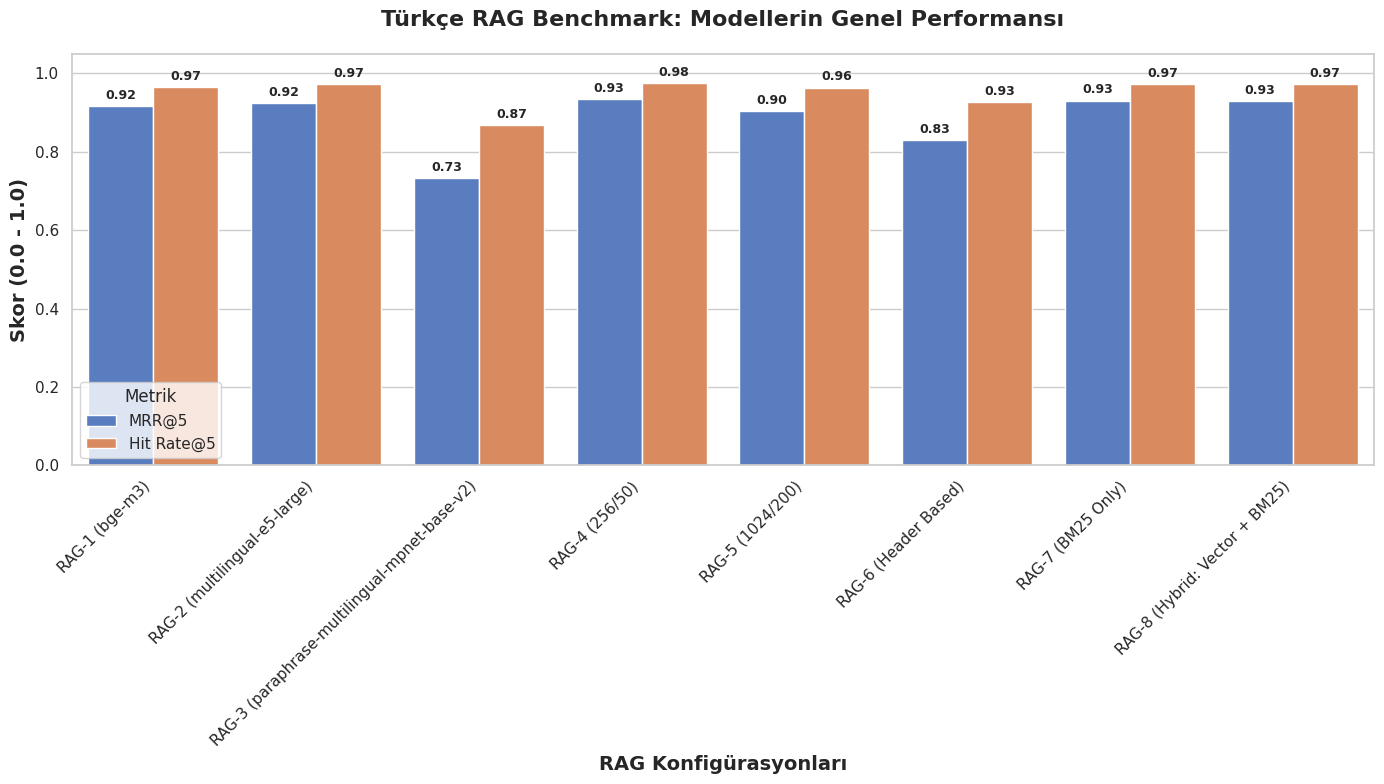

📊 Genel performans grafiği kaydedildi: ./results/overall_performance.png


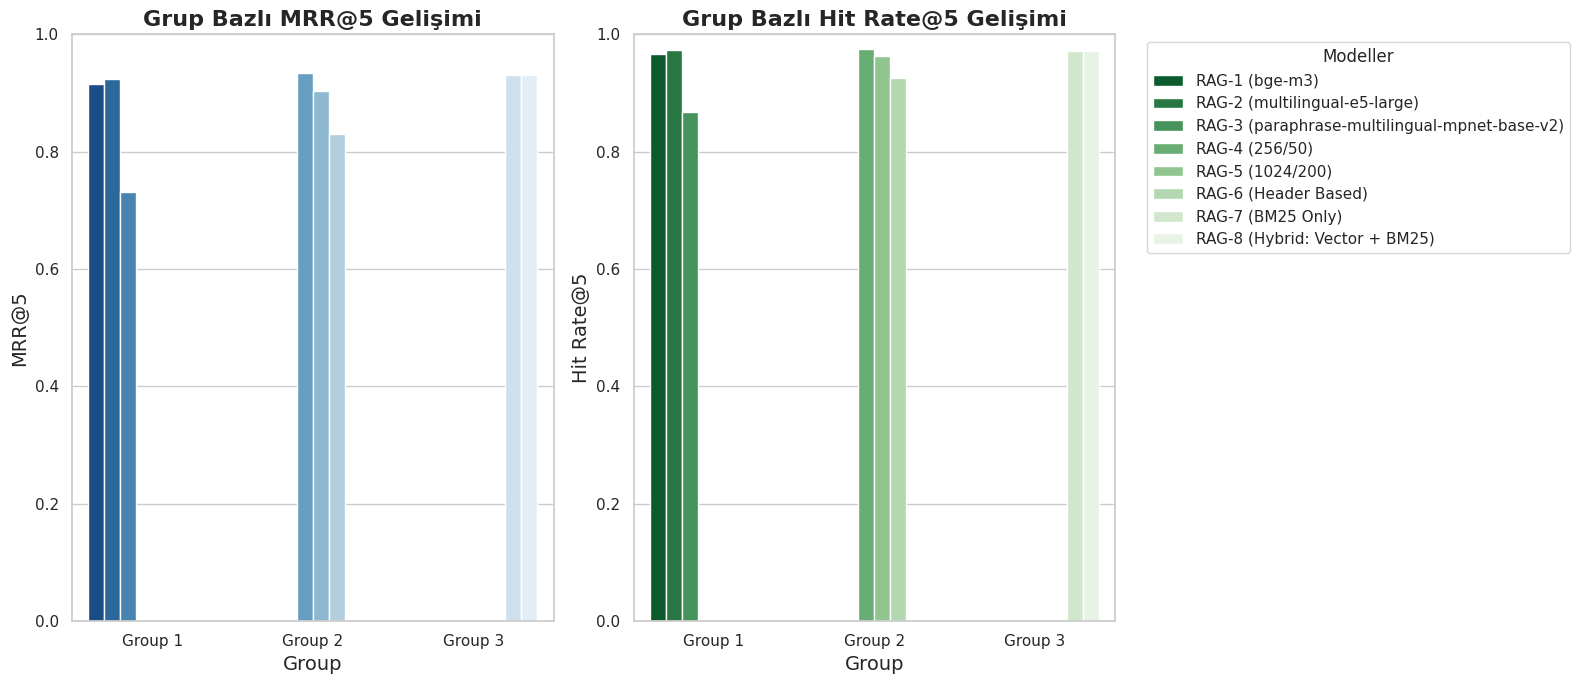

📊 Gruplar arası gelişim grafiği kaydedildi: ./results/progression_by_groups.png


In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Klasör Oluşturma
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

# Grafik Stil Ayarları
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 18,
})

df_plot = pd.DataFrame(all_results)

# Sütun isimlerini grafikte beklenen formatta olacak şekilde düzenliyoruz
df_plot = df_plot.rename(columns={"System": "Model", "HitRate@5": "Hit Rate@5"})

# GRAFİK 1: TÜM MODELLERİN KARŞILAŞTIRILMASI
fig, ax = plt.subplots(figsize=(14, 8))
df_melted = df_plot.melt(
    id_vars=["Model"],
    value_vars=["MRR@5", "Hit Rate@5"],
    var_name="Metrik",
    value_name="Skor",
)
sns.barplot(data=df_melted, x="Model", y="Skor", hue="Metrik", palette="muted", ax=ax)
ax.set_title("Türkçe RAG Benchmark: Modellerin Genel Performansı", pad=20, fontweight="bold")
ax.set_xlabel("RAG Konfigürasyonları", fontweight="bold")
ax.set_ylabel("Skor (0.0 - 1.0)", fontweight="bold")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}",
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="semibold")

plt.tight_layout()
overall_plot_path = os.path.join(output_dir, "overall_performance.png")
plt.savefig(overall_plot_path, dpi=300)
plt.show()
print(f"📊 Genel performans grafiği kaydedildi: {overall_plot_path}")

# GRAFİK 2: GRUP BAZLI GELİŞİM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=df_plot, x="Group", y="MRR@5", hue="Model", dodge=True, palette="Blues_r", ax=ax1)
ax1.set_title("Grup Bazlı MRR@5 Gelişimi", fontweight="bold")
ax1.set_ylim(0, 1.0)
ax1.get_legend().remove()

sns.barplot(data=df_plot, x="Group", y="Hit Rate@5", hue="Model", dodge=True, palette="Greens_r", ax=ax2)
ax2.set_title("Grup Bazlı Hit Rate@5 Gelişimi", fontweight="bold")
ax2.set_ylim(0, 1.0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Modeller")

plt.tight_layout()
progression_plot_path = os.path.join(output_dir, "progression_by_groups.png")
plt.savefig(progression_plot_path, dpi=300)
plt.show()
print(f"📊 Gruplar arası gelişim grafiği kaydedildi: {progression_plot_path}")